# 処理内容

- Inter-Trial Coherenceを確認し、click train刺激の影響が大きな電極を確認する
- ITCの高い電極に対して、以下のTime-Frequency図を描画する
    - ITC
    - evoked power
    - induced power
    - Phase-Locking Angle
- save as .npz

In [1]:
import pathlib
dir_path = pathlib.Path.home()/pathlib.Path('OneDrive/eeg_data/4072_0623_1')
assert dir_path.exists()
import matplotlib.pyplot as plt
import mne

`standard`及び`deviant`刺激呈示時をt=0としたepochsを読み込む。
passive及びactiveは回答ありなしの条件、1,2,3はblock

{
    'passive1':mne.Epochs,
    'passive2':mne.Epochs,
    'passive3':mne.Epochs,
    'active1':mne.Epochs,
    'active2':mne.Epochs,
    'active3':mne.Epochs,
}

In [2]:
epochs_dict = {
    file_name.stem.split('-epo')[0]:mne.read_epochs(
        file_name, preload=True
        ) for file_name in dir_path.glob('*-epo.fif.gz')
}

Reading /home/yi/OneDrive/eeg_data/4072_0623_1/passive2-epo.fif.gz ...
    Found the data of interest:
        t =    -399.90 ...     700.20 ms
        0 CTF compensation matrices available
162 matching events found
Applying baseline correction (mode: mean)
Not setting metadata
0 projection items activated
Reading /home/yi/OneDrive/eeg_data/4072_0623_1/active3-epo.fif.gz ...
    Found the data of interest:
        t =    -399.90 ...     700.20 ms
        0 CTF compensation matrices available
197 matching events found
Applying baseline correction (mode: mean)
Not setting metadata
0 projection items activated
Reading /home/yi/OneDrive/eeg_data/4072_0623_1/passive3-epo.fif.gz ...
    Found the data of interest:
        t =    -399.90 ...     700.20 ms
        0 CTF compensation matrices available
186 matching events found
Applying baseline correction (mode: mean)
Not setting metadata
0 projection items activated
Reading /home/yi/OneDrive/eeg_data/4072_0623_1/active1-epo.fif.gz ...
    Fou

epochs_dictにそれぞれのblockをまとめたepochsを作成する

In [3]:
for pa in ['passive', 'active']:
    epochs_dict[pa] = mne.concatenate_epochs([epochs_dict[pa+str(i+1)] for i in range(3)])

520 matching events found
Applying baseline correction (mode: mean)
Not setting metadata
0 bad epochs dropped
592 matching events found
Applying baseline correction (mode: mean)
Not setting metadata
0 bad epochs dropped


`standard` epochと`deviant` epochの数を合わせるために、'passive'条件からランダムに`standard` epochを削除する

In [4]:
import random

passive = epochs_dict['passive']
standard = len(passive['standard'])
deviant = len(passive['deviant'])
passive_standard = passive['standard'].drop(
    list(set(range(standard)) - set(random.choices(list(range(standard)), k=deviant)))
)

Dropped 420 epochs: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 59, 60, 61, 62, 63, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 136, 137, 138, 139, 141, 142, 143, 144, 146, 148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 23

Not setting metadata
No baseline correction applied


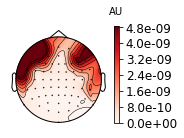

In [5]:
import numpy
freqs = numpy.arange(5., 60., 1.)
power = mne.time_frequency.tfr_morlet(
    passive_standard,
    freqs=freqs,
    n_cycles=freqs/2.,
    return_itc=False,
    average=False,
#    output='complex'
)
_ = power.average().plot_topomap(fmin=35., fmax=45.)


No baseline correction applied


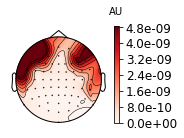

In [6]:
induced_power = power.average()
_ = induced_power.plot_topomap(fmin=35., fmax=45.)

No baseline correction applied


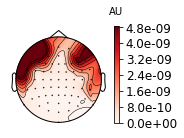

No baseline correction applied


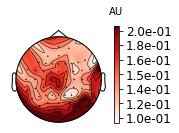

In [7]:
averaged_power, averaged_itc = mne.time_frequency.tfr_morlet(
    passive_standard,
    freqs=freqs,
    n_cycles=freqs/2.,
    return_itc=True,
    average=True,
#    output='complex'
)
_ = averaged_power.plot_topomap(fmin=35., fmax=45.)
_ = averaged_itc.plot_topomap(fmin=35., fmax=45., vmin=0.1, vmax=0.2)

In [8]:
#TF_MAP
#itc
#evoked poewr 
#induced power
#save .npz  

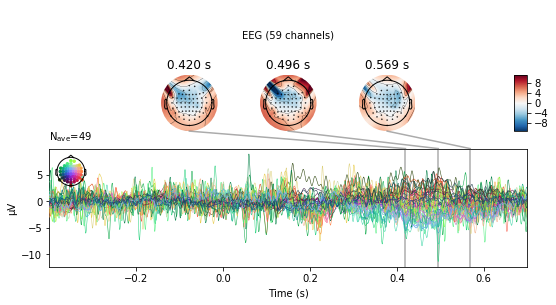

No baseline correction applied


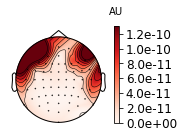

In [9]:
evoked_standard = passive_standard.average()
_ = evoked_standard.plot_joint()
evoked_power = mne.time_frequency.tfr_morlet(evoked_standard, freqs=freqs, n_cycles=freqs/2., return_itc=False)
_ = evoked_power.plot_topomap(fmin=35., fmax=45.)

No baseline correction applied


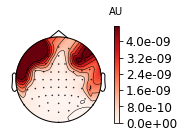

In [10]:
_ = (induced_power - evoked_power).plot_topomap(fmin=35., fmax=45.)